<a href="https://colab.research.google.com/github/Prabhu12345678/Generative_AI_Skills/blob/main/knowledge_graph_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import networkx as nx

In [40]:
# Loading the data from file commited on main branch of https://raw.githubusercontent.com/Prabhu12345678/Generative_AI_Skills
# https://raw.githubusercontent.com/Prabhu12345678/Generative_AI_Skills/refs/heads/main/dbpedia.csv

df = pd.read_csv('https://raw.githubusercontent.com/Prabhu12345678/Generative_AI_Skills/refs/heads/main/dbpedia.csv',
names=['subject','predicate','object'])

display(df.head())
df.info()

df = df.head(200)

,subject,predicate,object
0,subject,predicate,object
1,Taj Mahal,located_in_city,Tokyo
2,Colosseum_Section_175,belongs_to_complex,Colosseum
3,Barack Obama_FanClub_53,follows_career_of,Barack Obama
4,Nelson Mandela_FanClub_104,follows_career_of,Nelson Mandela


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   subject    5001 non-null   object
 1   predicate  5001 non-null   object
 2   object     5001 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [41]:
import pandas as pd
import networkx as nx
# Initialize Direct Graph
G = nx.DiGraph()

# Add subject, predicate and object as nodes
for _, row in df.iterrows():
    subject = row['subject']
    predicate = row['predicate']
    obj = row['object']

    # Add nodes and relationships
    G.add_node(subject, type = 'subject')
    G.add_node(obj, type = 'object')
    G.add_edge(subject, obj, predicate = predicate)
print(f'Graph is having {G.number_of_nodes()} nodes and {G.number_of_edges()} edges')

Graph is having 216 nodes and 200 edges


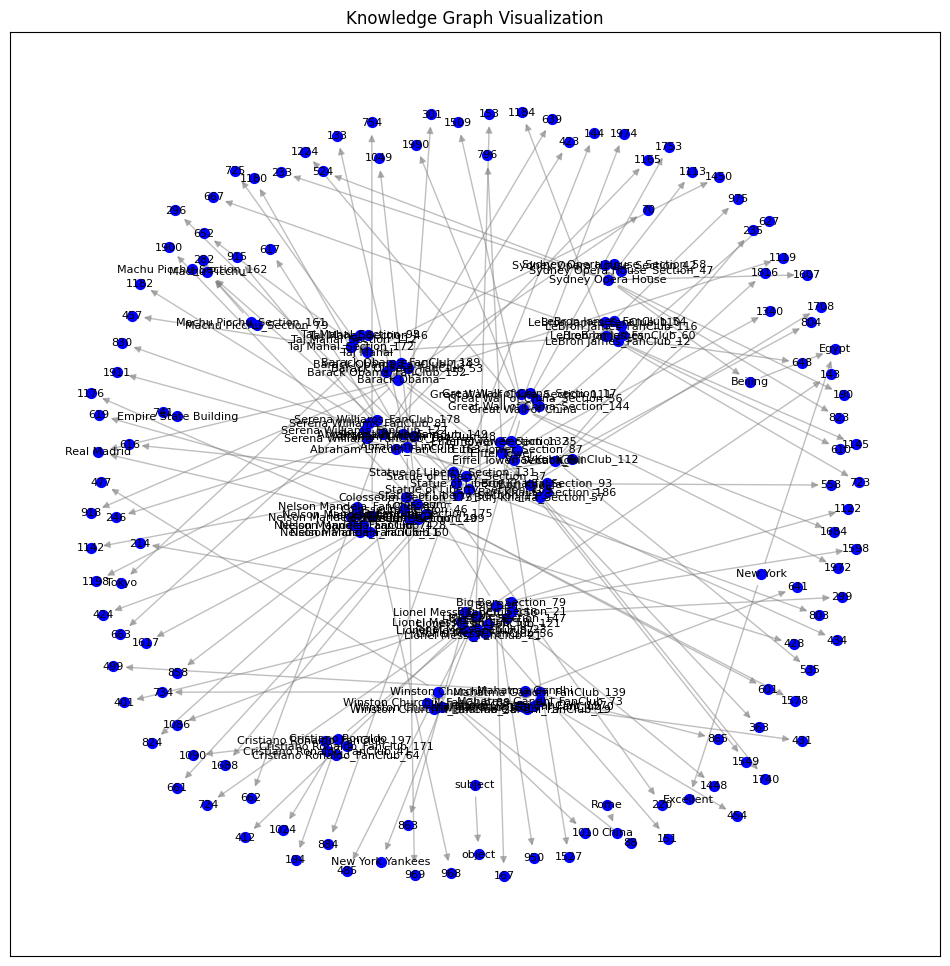

In [42]:
import matplotlib.pyplot as plt

# Nodes layout
pos = nx.spring_layout(G)
fig1 = plt.figure(figsize=(12,12))

# Nodes
nx.draw_networkx_nodes(G, pos, node_color='blue', node_size=50)

# Edges
nx.draw_networkx_edges(G, pos, edge_color='grey', width=1.0, alpha=0.5, arrows=True)

# Labels
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

plt.title('Knowledge Graph Visualization')
plt.show()


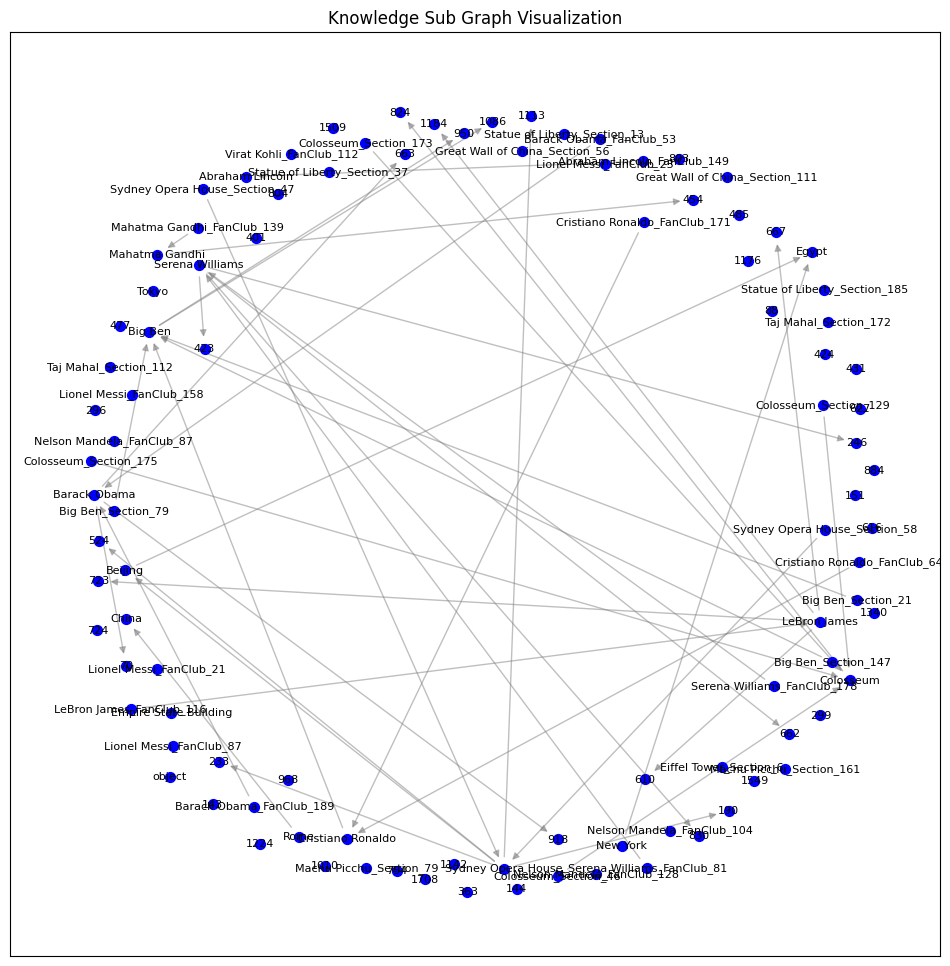

In [43]:
from networkx.classes.function import subgraph
import plotly.graph_objects as go
import random

# Reducing the nodes size to 100
sampled_nodes = random.sample(list(G.nodes()), 100)
subgraph = G.subgraph(sampled_nodes)

pos = nx.spring_layout(subgraph, 42)
fig2 = plt.figure(figsize=(12,12))

# Nodes
nx.draw_networkx_nodes(subgraph, pos, node_color='blue', node_size=50)

# Edges
nx.draw_networkx_edges(subgraph, pos, edge_color='grey', width=1.0, alpha=0.5, arrows=True)

# Labels
nx.draw_networkx_labels(subgraph, pos, font_size=8, font_family='sans-serif')

plt.title('Knowledge Sub Graph Visualization')
plt.show()